### Demonstration of dispa functions for estimation of error from simulated data

#### Using estimate_snr_error() to estimate error derived from random Gaussian noise in the data
User input parameters allow flexible specification of simulated data properties to match an empirical dataset of interest. The function estimates the error in the estimate of phase shift that is caused by Gaussian noise in the data. Data with lower SNR is expected to result in larger errors on estimated phase shift. 

In [1]:
from dispa import estimate_snr_error

##### Define parameters used to generate simulated datasets

In [2]:
parameters = {"n":4096, "dw":0.001, "SNR":1000, "bf":100, "SW_p":1000, "OFFSET":5, "nc_proc":11}

##### Run the estimate_snr_error() function to estimate error in estimated phase shifts 

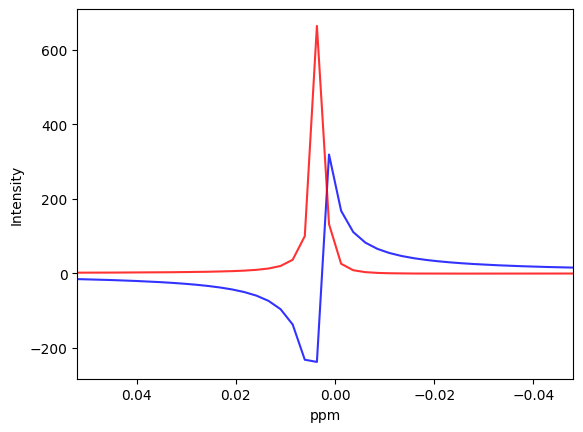

CPU times: user 1.49 s, sys: 19 ms, total: 1.51 s
Wall time: 1.51 s


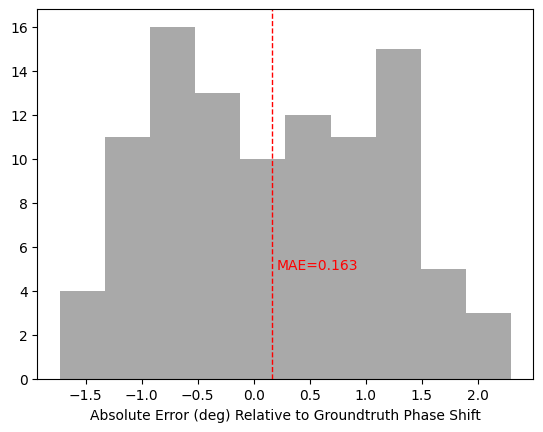

In [3]:
%%time
ps_estimates, ps_errors, mean_angle, mean_abs_err = estimate_snr_error(focal_width=0.2, focal_center=0.2, parameters=parameters, output_folder="test_snr_error_esimator", 
                   theta_shift=90, ppm_roi=(0.15,0.25), num_reps=100, plot=True, write_sims=False)

#### Using the estimate_separation_error() function to estimate error in estimated phase shifts due to peak overlap
This function takes user input to generate simulated datasets with and without phase shifts. It uses a procedure that walks out from the center of a "focal" peak with increasing ROI window size to estimate the error on the phase shift estimate for the focal peak that is caused by overlap with another nearby peak that has no phase shift. Greater overlap between peaks is expected to produce larger errors in estimated phase shift of the focal peak. The size of the ROI region can be tuned to minimize this separation/overlap error by reducing the amount of "contaminating" signal from the non-focal peak. 

In [4]:
from dispa import estimate_separation_error

##### Define parameters used to generate simulated datasets

In [5]:
parameters = {"n":4096, "dw":0.001, "SNR":1000, "bf":100, "SW_p":1000, "OFFSET":5, "nc_proc":11}

##### Run the estimate_separation_error function to estimate error in estimated phase shifts 
The default SNR value is set to 10,000, which results in very low-noise data. This input argument can be changed to reflect the SNR of the empirical dataset being compared. 

/home/lcwheeler/mambaforge/envs/enmr/lib/python3.13/site-packages/nmrglue/fileio/bruker.py:394: UserWarning: Error reading the pulse program
  warn('Error reading the pulse program')


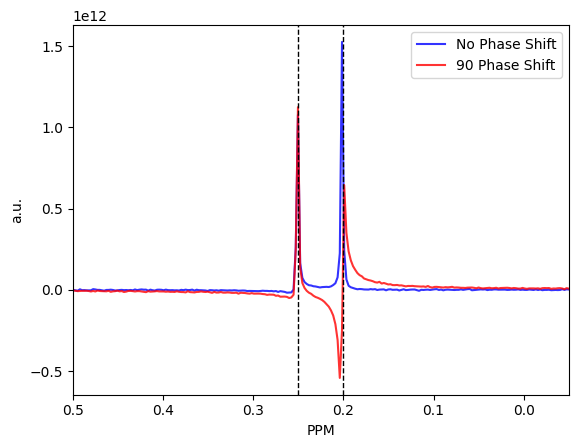

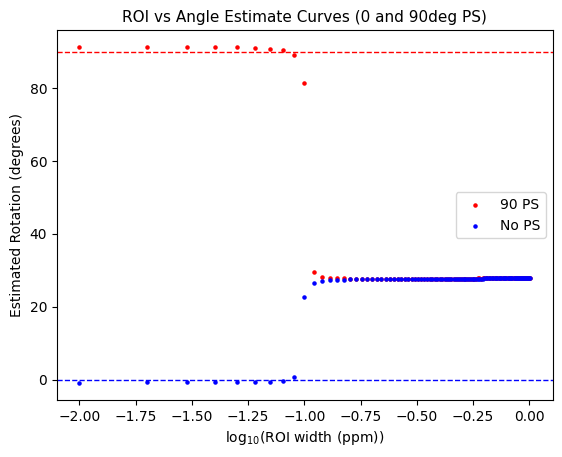

In [6]:
expansions_p0, expansions_p10, min_err_focal, min_err_nops = estimate_separation_error(focal_width=0.2, width2=0.1, focal_intensity=1000, intensity2=1000, 
                                                                                       focal_center=20, center2=25, parameters=parameters, 
                                                                                       output_folder="test_separation_error_estimator", 
                                                                                       theta_ps=90, snr=500, plot=True)

##### Examine the minimum error on the phase shift estimate for the focal peak

In [7]:
print(min_err_focal)

-1.2759999999999962
